# E1 + Scaling

Train Transformer-small vs Hyena-small (WikiText-2) → `results/*.csv` + plot.

**Dùng:** Runtime → T4 GPU → Run all (~5–10 phút, cuối notebook tải `results.zip`).

## 1. Kiểm tra GPU

In [1]:
!nvidia-smi -L
import torch
print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'CHƯA bật GPU! Vào Runtime > Change runtime type > T4 GPU rồi Run all lại.'

GPU 0: Tesla T4 (UUID: GPU-c15e1398-7441-c424-4128-bbb8e7c36e1f)
torch 2.11.0+cu128 | CUDA available: True


## 2. Clone repo + cài thư viện
Thêm `datasets` + `transformers` (các lib khác đã có sẵn trên Colab).

In [ ]:
%cd /content
![ -d CS2308-Hyena-Hierarchy-Long-Context-NLP ] || git clone https://github.com/minhtien0498/CS2308-Hyena-Hierarchy-Long-Context-NLP.git
%cd CS2308-Hyena-Hierarchy-Long-Context-NLP
!git pull -q
# Pin version để tránh HfUriError (datasets/hub mới đổi quy ước tên dataset)
!pip install -q "datasets<3" "huggingface_hub<0.26" transformers

## 3. E1 — Train PPL (L=256)
5 epoch cho nhanh (tăng `--epochs 20` nếu muốn PPL đẹp hơn). Lưu `results/E1_*_L256.csv`.

In [3]:
!python train.py --model transformer --seq_len 256 --epochs 5 --batch_size 16

[Device] GPU: Tesla T4

  Run: transformer_L256_20260614_155722
  Model: transformer | Seq len: 256
  Epochs: 5 | Batch size: 16

[Data] Loading train dataloader...
[Tokenizer] Downloading gpt2...
tokenizer_config.json: 100% 26.0/26.0 [00:00<00:00, 88.6kB/s]
vocab.json: 100% 1.04M/1.04M [00:00<00:00, 5.95MB/s]
merges.txt: 100% 456k/456k [00:00<00:00, 3.26MB/s]
tokenizer.json: 100% 1.36M/1.36M [00:00<00:00, 11.1MB/s]
[Dataset] Loading WikiText-2 split='train'...
README.md: 100% 10.5k/10.5k [00:00<00:00, 38.7MB/s]
Traceback (most recent call last):
  File "/content/CS2308-Hyena-Hierarchy-Long-Context-NLP/train.py", line 329, in <module>
    train(args)
  File "/content/CS2308-Hyena-Hierarchy-Long-Context-NLP/train.py", line 163, in train
    train_loader = get_dataloader(
                   ^^^^^^^^^^^^^^^
  File "/content/CS2308-Hyena-Hierarchy-Long-Context-NLP/data/preprocess.py", line 115, in get_dataloader
    tokens = load_and_tokenize(split, tokenizer)
             ^^^^^^^^^^^^^^^^

In [4]:
!python train.py --model hyena --seq_len 256 --epochs 5 --batch_size 16

[Device] GPU: Tesla T4

  Run: hyena_L256_20260614_155738
  Model: hyena | Seq len: 256
  Epochs: 5 | Batch size: 16

[Data] Loading train dataloader...
[Tokenizer] Loading from cache: .cache/gpt2_tokenizer
[Dataset] Loading WikiText-2 split='train'...
Traceback (most recent call last):
  File "/content/CS2308-Hyena-Hierarchy-Long-Context-NLP/train.py", line 329, in <module>
    train(args)
  File "/content/CS2308-Hyena-Hierarchy-Long-Context-NLP/train.py", line 163, in train
    train_loader = get_dataloader(
                   ^^^^^^^^^^^^^^^
  File "/content/CS2308-Hyena-Hierarchy-Long-Context-NLP/data/preprocess.py", line 115, in get_dataloader
    tokens = load_and_tokenize(split, tokenizer)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/CS2308-Hyena-Hierarchy-Long-Context-NLP/data/preprocess.py", line 80, in load_and_tokenize
    dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=split)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

## 4. E2/E3 — Runtime/memory scaling theo seq_len

In [5]:
!python evaluate.py --model transformer --scaling --seq_lens 256 512 1024 --batch_size 8
!python evaluate.py --model hyena --scaling --seq_lens 256 512 1024 2048 --batch_size 8


  Scaling Experiment: TRANSFORMER
  Seq lengths: [256, 512, 1024]

   Seq Len |    Time (ms) |   Mem (MB) |   Throughput (tok/s)
------------------------------------------------------------
       256 |        18.39 |      466.3 |               111338
       512 |        39.33 |      862.7 |               104153
      1024 |        90.82 |     1654.8 |                90197

💾 Saved: results/E2_transformer_scale.csv

  Scaling Experiment: HYENA
  Seq lengths: [256, 512, 1024, 2048]

   Seq Len |    Time (ms) |   Mem (MB) |   Throughput (tok/s)
------------------------------------------------------------
       256 |        19.59 |      466.7 |               104566
       512 |        38.47 |      862.3 |               106474
      1024 |        76.09 |     1651.4 |               107666
      2048 |       151.59 |     3231.9 |               108079

💾 Saved: results/E3_hyena_scale.csv


## 5. Xem kết quả + vẽ plot PPL


=== results/E2_transformer_scale.csv ===


,model,seq_len,time_ms,peak_mem_mb,throughput
0,transformer,256,18.394454,466.312500,111337.909550
1,transformer,512,39.326835,862.697266,104152.801161
2,transformer,1024,90.823030,1654.763672,90197.386962



=== results/E3_hyena_scale.csv ===


,model,seq_len,time_ms,peak_mem_mb,throughput
0,hyena,256,19.585639,466.697266,104566.411888
1,hyena,512,38.469436,862.332031,106474.136335
2,hyena,1024,76.087080,1651.398438,107666.110917
3,hyena,2048,151.593019,3231.937500,108078.855638


Chưa có results/E1_transformer_L256.csv
Chưa có results/E1_hyena_L256.csv


/tmp/ipykernel_711/4084141775.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()


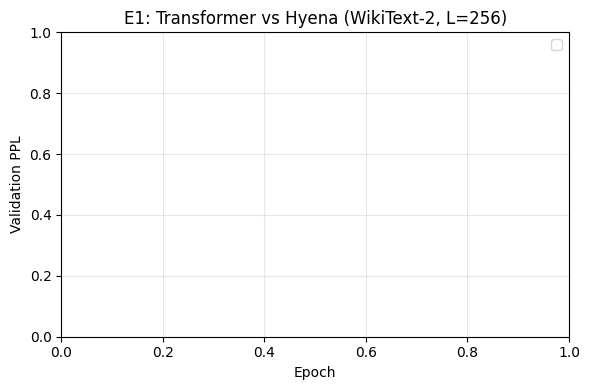

In [6]:
import glob, pandas as pd, matplotlib.pyplot as plt

for f in sorted(glob.glob('results/*.csv')):
    print('\n===', f, '===')
    display(pd.read_csv(f))

# Plot val PPL theo epoch cho 2 model E1
plt.figure(figsize=(6,4))
for model in ['transformer', 'hyena']:
    fp = f'results/E1_{model}_L256.csv'
    try:
        df = pd.read_csv(fp)
        plt.plot(df['epoch'], df['val_ppl'], marker='o', label=model)
    except FileNotFoundError:
        print('Chưa có', fp)
plt.xlabel('Epoch'); plt.ylabel('Validation PPL'); plt.title('E1: Transformer vs Hyena (WikiText-2, L=256)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('results/plots/E1_ppl.png', dpi=120)
plt.show()

## 6. Tải kết quả về máy

In [7]:
!zip -r -q results.zip results
from google.colab import files
files.download('results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>